In [ ]:
!pip install scikit-uplift pandas scikit-learn matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.0 MB/s eta 0:00:00


In [ ]:
from sklift.datasets import fetch_hillstrom
import pandas as pd

dataset = fetch_hillstrom(target_col='visit')
data, target, treatment_full = dataset.data, dataset.target, dataset.treatment

print(treatment_full.value_counts())
print(data.head())

Hillstrom dataset:   0%|          | 0.00/443k [00:00<?, ?iB/s]

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64
   recency history_segment  history  mens  womens   zip_code  newbie channel
0       10  2) $100 - $200   142.44     1       0  Surburban       0   Phone
1        6  3) $200 - $350   329.08     1       1      Rural       1     Web
2        7  2) $100 - $200   180.65     0       1  Surburban       1     Web
3        9  5) $500 - $750   675.83     1       0      Rural       1     Web
4        2    1) $0 - $100    45.34     1       0      Urban       0     Web


In [ ]:
mask = treatment_full.isin(['Womens E-Mail', 'No E-Mail'])
X = data[mask].reset_index(drop=True)
y = target[mask].reset_index(drop=True)
treat = (treatment_full[mask] == 'Womens E-Mail').astype(int).reset_index(drop=True)

In [ ]:
print(f"Treatment group visit rate: {y[treat==1].mean():.3f}")
print(f"Control group visit rate: {y[treat==0].mean():.3f}")
print(f"Naive average treatment effect: {y[treat==1].mean() - y[treat==0].mean():.3f}")

Treatment group visit rate: 0.151
Control group visit rate: 0.106
Naive average treatment effect: 0.045


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

X_enc = pd.get_dummies(X, drop_first=True)
X_train, X_val, y_train, y_val, trmnt_train, trmnt_val = train_test_split(
    X_enc, y, treat, test_size=0.3, random_state=42, stratify=treat
)

In [ ]:
from sklift.models import TwoModels
from sklearn.linear_model import LogisticRegression

tm = TwoModels(
    estimator_trmnt=LogisticRegression(max_iter=1000),
    estimator_ctrl=LogisticRegression(max_iter=1000),
    method='vanilla'
)
tm = tm.fit(X_train, y_train, trmnt_train)
uplift_preds = tm.predict(X_val)

In [ ]:
# 1. Filter data to ONLY look at people who got the email
mask_treated_train = (trmnt_train == 1)
X_train_treated = X_train[mask_treated_train]
y_train_treated = y_train[mask_treated_train]

# 2. Train a normal, "naive" model on just these people
naive_model = LogisticRegression(max_iter=1000)
naive_model.fit(X_train_treated, y_train_treated)

# 3. Predict scores for our test group
naive_preds = naive_model.predict_proba(X_val)[:, 1]

In [ ]:
!pip install scikit-learn==1.1.3 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 22.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


Qini coefficient: 0.064
Uplift AUC: 0.030
Uplift captured targeting top 30% by predicted uplift: 0.065


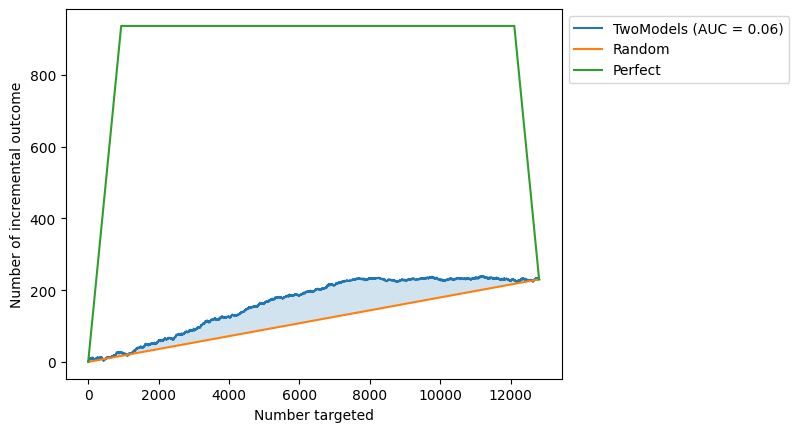

In [15]:
# --- THE FIX: Trick the system into ignoring the missing code ---
import sklearn.utils
sklearn.utils.check_matplotlib_support = lambda x: None
# ----------------------------------------------------------------

# Now the original Day 3 code continues normally!
from sklift.metrics import qini_auc_score, uplift_auc_score, uplift_at_k, weighted_average_uplift
from sklift.viz import plot_qini_curve, plot_uplift_curve
import matplotlib.pyplot as plt

qini_coef = qini_auc_score(y_true=y_val, uplift=uplift_preds, treatment=trmnt_val)
uplift_auc = uplift_auc_score(y_true=y_val, uplift=uplift_preds, treatment=trmnt_val)
u_at_30 = uplift_at_k(y_true=y_val, uplift=uplift_preds, treatment=trmnt_val, strategy='overall', k=0.3)

print(f"Qini coefficient: {qini_coef:.3f}")
print(f"Uplift AUC: {uplift_auc:.3f}")
print(f"Uplift captured targeting top 30% by predicted uplift: {u_at_30:.3f}")

fig, ax = plt.subplots(1, 1)
plot_qini_curve(y_val, uplift_preds, trmnt_val, perfect=True, name='TwoModels', ax=ax)
plt.savefig('qini_curve.png', dpi=150)

In [13]:
results = pd.DataFrame({'uplift_pred': uplift_preds, 'treatment': trmnt_val.values, 'y': y_val.values})
results['decile'] = pd.qcut(results['uplift_pred'], 10, labels=False, duplicates='drop')

decile_table = results.groupby('decile').apply(
    lambda d: d.loc[d.treatment==1, 'y'].mean() - d.loc[d.treatment==0, 'y'].mean()
).sort_index(ascending=False)

print(decile_table)

decile
9    0.046591
8    0.074306
7    0.076996
6    0.072452
5    0.043924
4    0.054525
3   -0.005094
2    0.004459
1   -0.000502
0    0.003793
dtype: float64


/tmp/ipykernel_4696/3602184386.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  decile_table = results.groupby('decile').apply(


In [16]:
# Calculate Qini scores for both models
qini_uplift = qini_auc_score(y_true=y_val, uplift=uplift_preds, treatment=trmnt_val)
qini_naive = qini_auc_score(y_true=y_val, uplift=naive_preds, treatment=trmnt_val)

print("--- THE ROI SHOWDOWN ---")
print(f"Smart Uplift Model Score: {qini_uplift:.3f}")
print(f"Naive Churn Model Score:  {qini_naive:.3f}")

--- THE ROI SHOWDOWN ---
Smart Uplift Model Score: 0.064
Naive Churn Model Score:  0.034
